# Electoral Dashboard Exploration

This notebook connects to your local Postgres database to fetch the electoral parties, raw votes, and individual candidate names extracted from the Spanish Ministry of Interior datasets. 

We use **Plotly** to generate a fully interactive, geometric parliament hemicycle where you can hover over every single seat to see the name of the exact politician sitting there! 🗳️

In [ ]:
%pip install psycopg2-binary pandas matplotlib plotly nbformat>=4.2.0 ipywidgets python-dotenv seaborn

In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import math
from dotenv import load_dotenv
import os

load_dotenv('../.env')

def fetch_electoral_data(city_name):
    conn = psycopg2.connect(
        dbname=os.getenv('POSTGRES_DB', 'bikesforcities'),
        user=os.getenv('POSTGRES_USER', 'postgres'),
        password=os.getenv('POSTGRES_PASSWORD', 'postgres'),
        host='localhost',
        port='5432'
    )
    query_results = """
        SELECT ce.party, ce.councilors, ce.votes
        FROM city_elections ce
        JOIN cities c ON c.id = ce.city_id
        WHERE c.name ILIKE %s AND (ce.councilors > 0 OR ce.votes > 1000)
        ORDER BY ce.votes DESC
    """
    df_results = pd.read_sql_query(query_results, conn, params=(f'%{city_name}%',))
    
    query_candidates = """
        SELECT cc.party, cc.name
        FROM city_councilors cc
        JOIN cities c ON c.id = cc.city_id
        WHERE c.name ILIKE %s AND cc.elected = TRUE
    """
    df_councilors = pd.read_sql_query(query_candidates, conn, params=(f'%{city_name}%',))
    
    conn.close()
    return df_results, df_councilors

### Interactive Parliament Hemicycle (Plotly)
Instead of static visualizations, we geometrically map Plotly Scatter endpoints arranged concentrically. We inject the individual candidates' names into `hover_texts` so hovering over any seat reveals the specific elected politician!

In [8]:
color_map = {
    'PP': '#1d84ce',
    'PARTIDO POPULAR': '#1d84ce',
    'PSOE': '#ef1c27',
    'PARTIDO SOCIALISTA': '#ef1c27',
    'VOX': '#52aa25',
    'MÁS MADRID': '#0ed3a2',
    'MAS MADRID': '#0ed3a2',
    'PODEMOS': '#6b2e68',
    'IU': '#6b2e68',
    'CS': '#eb6109',
    'CIUDADANOS': '#eb6109',
    'ERC': '#ffb232',
    'JUNTS': '#ffb232',
    'BILDU': '#a5d75d',
    'PNV': '#008000',
    'COMPROMIS': '#ce5a18',
}

ideology_map = {
    'CUP': 10, 'ERC': 15, 'BILDU': 15, 'BNG': 15,
    'PODEMOS': 20, 'IU': 20, 'MAS MADRID': 25, 'MÁS MADRID': 25, 'COMPROMIS': 25,
    'PSOE': 40, 'PARTIDO SOCIALISTA': 40,
    'PNV': 50, 'CCa': 50,
    'CIUDADANOS': 60, 'CS': 60, 'JUNTS': 65,
    'PP': 80, 'PARTIDO POPULAR': 80,
    'VOX': 95
}

def get_color(party_name):
    party_upper = party_name.upper()
    # Match exact acronyms or distinct tokens within hyphenated blends
    for key, hex_color in color_map.items():
        if key == party_upper or key in party_upper.replace('-', ' ').split():
            return hex_color
            
    # Fallback to deterministic hash if unknown
    return '#' + hex(hash(party_name) & 0xFFFFFF)[2:].zfill(6)

def get_ideology_score(party_name):
    party_upper = party_name.upper()
    for key, score in ideology_map.items():
        if key == party_upper or key in party_upper.replace('-', ' ').split():
            return score
    return 50  # Default to center

def plot_parliament_interactive(df_results, df_councilors, city_name):
    df_seats = df_results[df_results['councilors'] > 0].copy()
    if df_seats.empty:
        print(f"No councilors found for {city_name}")
        return
        
    df_seats['ideology'] = df_seats['party'].apply(get_ideology_score)
    df_seats = df_seats.sort_values(by=['ideology', 'councilors'], ascending=[True, False])
    
    # Assign names sequentially to their parties' seats
    party_to_names = df_councilors.groupby('party')['name'].apply(list).to_dict()
    
    seat_parties = []
    seat_names = []
    for _, row in df_seats.iterrows():
        party = row['party']
        num_seats = int(row['councilors'])
        names = party_to_names.get(party, [f"{party} Candidate"] * num_seats)
        
        # Truncate or pad gracefully
        if len(names) < num_seats:
            names += [f"Unknown {party}"] * (num_seats - len(names))
            
        seat_parties.extend([party] * num_seats)
        seat_names.extend(names[:num_seats])

    total_seats = len(seat_parties)
    num_rings = max(3, int(math.sqrt(total_seats) / 1.6))
    radii = np.linspace(0.4, 1.0, num_rings)
    ring_capacities = radii / np.sum(radii)
    seats_per_ring = np.round(ring_capacities * total_seats).astype(int)
    
    diff = total_seats - np.sum(seats_per_ring)
    seats_per_ring[-1] += diff
    
    # Generate all geometric dots
    all_coords = []
    for i, r in enumerate(radii):
        n_seats = seats_per_ring[i]
        if n_seats <= 0: continue
        angles = np.linspace(np.pi, 0, n_seats)
        for theta in angles:
            all_coords.append((theta, r))
            
    # Sort strictly by Angle (descending from pi to 0), so we form pie slices!
    # Minus r guarantees we build the slice evenly from inside-out
    all_coords.sort(key=lambda x: (x[0], -x[1]), reverse=True)
    
    x_coords, y_coords, hover_texts, colors = [], [], [], []
    for i in range(min(total_seats, len(all_coords))):
        theta, r = all_coords[i]
        party = seat_parties[i]
        name = seat_names[i]
        
        x_coords.append(r * np.cos(theta))
        y_coords.append(r * np.sin(theta))
        hover_texts.append(f"<b>{name}</b><br>{party}")
        colors.append(get_color(party))

    # Generate Plotly trace
    fig = go.Figure(data=go.Scatter(
        x=x_coords, 
        y=y_coords,
        mode='markers',
        text=hover_texts,
        hoverinfo='text',
        showlegend=False,
        marker=dict(size=18, color=colors, line=dict(width=1, color='white'))
    ))
    
    # Adds clean legend names for unique parties only
    unique_parties = df_seats['party'].unique().tolist()
    for party in unique_parties:
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers', name=party, 
            marker=dict(size=12, color=get_color(party))
        ))

    fig.update_layout(
        title=dict(text=f"Ayuntamiento de {city_name.title()} (2023) - {total_seats} Seats", font=dict(size=24)),
        xaxis=dict(showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False, visible=False, scaleanchor="x", scaleratio=1),
        plot_bgcolor='white',
        height=550,
        hoverlabel=dict(bgcolor="white", font_size=14)
    )
    fig.show()

### Plotting Popular Vote
Visualizing the raw total vote count for the top 10 parties using seaborn.

In [9]:
def plot_votes_bar(df_results, city_name):
    if df_results.empty:
        print(f"No votes found for {city_name}")
        return
        
    df_votes = df_results.sort_values(by='votes', ascending=True).tail(10)
    colors = [get_color(p) for p in df_votes['party']]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_votes, x='votes', y='party', palette=colors)
    
    plt.title(f"Popular Vote in {city_name.title()} (2023)", fontsize=16, fontweight='bold')
    plt.xlabel("Total Votes", fontsize=12)
    plt.ylabel("", fontsize=12)
    
    # Strip lengthy descriptors 
    short_labels = [p[:30] + '...' if len(p) > 30 else p for p in df_votes['party']]
    ax.set_yticklabels(short_labels, fontsize=10)
    
    max_votes = max(df_votes['votes'])
    for i, v in enumerate(df_votes['votes']):
        plt.text(v + (max_votes * 0.01), i, f"{int(v):,}", va='center', fontsize=11)
        
    plt.xlim(0, max_votes * 1.15)
    plt.tight_layout()
    plt.show()

### Generate the Visualizations
Run the cells below for actual live data visualization!

/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/4085301132.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_results = pd.read_sql_query(query_results, conn, params=(f'%{city_name}%',))
/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/4085301132.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_councilors = pd.read_sql_query(query_candidates, conn, params=(f'%{city_name}%',))


/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/1392271359.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_votes, x='votes', y='party', palette=colors)
/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/1392271359.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(short_labels, fontsize=10)


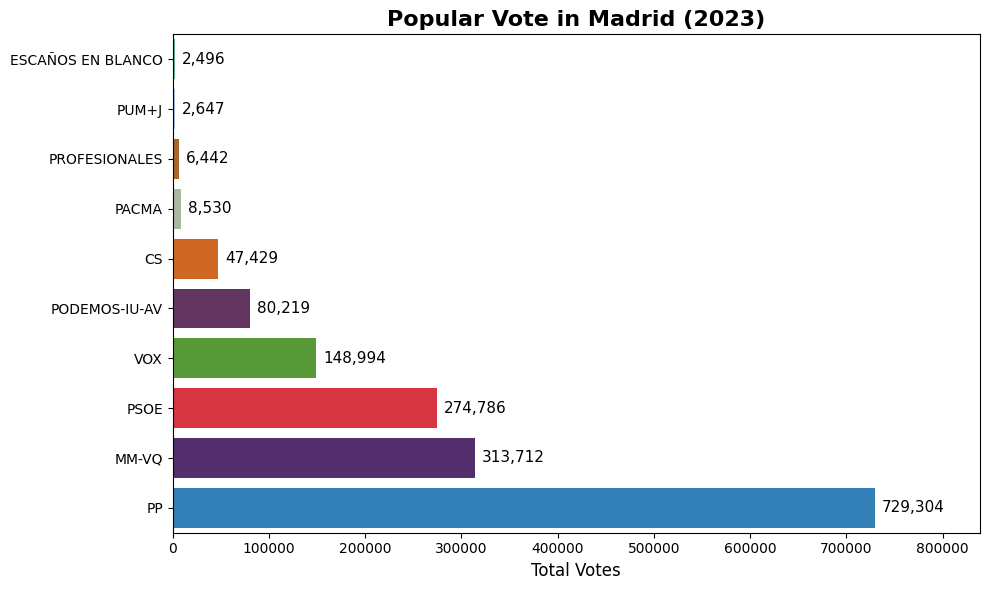

In [10]:
# Example 1: Madrid
df_madrid_res, df_madrid_coun = fetch_electoral_data("Madrid")
plot_parliament_interactive(df_madrid_res, df_madrid_coun, "Madrid")
plot_votes_bar(df_madrid_res, "Madrid")

In [11]:
# Example 2: Barcelona
df_bcn_res, df_bcn_coun = fetch_electoral_data("Barcelona")
plot_parliament_interactive(df_bcn_res, df_bcn_coun, "Barcelona")
plot_votes_bar(df_bcn_res, "Barcelona")

No councilors found for Barcelona
No votes found for Barcelona


/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/4085301132.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_results = pd.read_sql_query(query_results, conn, params=(f'%{city_name}%',))
/var/folders/q_/kvl1vqd97qq_hn08p839948m0000gn/T/ipykernel_47557/4085301132.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_councilors = pd.read_sql_query(query_candidates, conn, params=(f'%{city_name}%',))
